# Thesaurus word selection

**Recipe 12** · Level 2 (Easy) · Decision type: `Choice`

Choose a context-appropriate synonym from a supplied thesaurus list while retaining the original word when no alternative preserves its meaning.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

A thesaurus-style word selector for four target words (`happy`, `big`, `quick`, `angry`). For each sentence, Python supplies its own small set of candidate synonyms -- built fresh per sentence, not shared by every sentence that happens to use the same word -- plus a fixed fallback, `keep_original`, for a sentence where none of the candidates preserve the word's meaning. Jev reads one sentence and picks exactly one option. Python then accepts that choice only when it is one Jev was actually offered and its `confidence` clears a threshold chosen on `validation` and frozen afterward; anything else goes to an explicit `review` outcome. Forty sentences carry a gold label (a list of every option that preserves the meaning, since more than one synonym can fit) across `validation` and `test`; three more are shown in this notebook but never scored. By the end you will have looked at individual typed answers -- a clear pick, a correct `keep_original`, and a wrong, confident one -- then the rule, then an evaluation that reports the share of selections inside each sentence's acceptable set, how correctly the rule uses `keep_original`, and the coverage, accuracy and risk the frozen threshold buys.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 43 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    evaluate_outcomes,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import apply_style, plot_answer_probabilities, run_header, show_answer

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 43 examples in fixtures/ has its own candidate list, so its own question;
# this cache makes sure a sentence that is shown individually and later scored in its split is
# decided once, so the whole notebook makes exactly 43 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        questions = helpers.build_questions(example.fields["word"], example.fields["candidates"])
        state = helpers.build_state(example.fields)
        answered[example.id] = backend.decide(state, questions)["synonym"]
    return answered[example.id]


run_header(
    12,
    "Thesaurus word selection",
    backend=backend,
    n_examples=len(scored),
)

Recipe 12: Thesaurus word selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 40 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: an `item_id`, the target `word`, the `sentence` it appears in, and this sentence's own `candidates` list. `build_state` passes on the word and the sentence only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model, and the candidate list shapes the question below rather than the state.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-happy-clear"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "item_id": "d01-happy-clear",
  "word": "happy",
  "sentence": "She was happy and couldn't stop smiling all evening after the reunion.",
  "candidates": [
    "joyful",
    "cheerful",
    "glad"
  ]
}
Jev sees:
{
  "word": "happy",
  "sentence": "She was happy and couldn't stop smiling all evening after the reunion."
}


## The questions

There is one question, and it asks one thing: which of the supplied words, if any, could replace the target word here without changing the sentence's meaning? A `Choice` fits because the candidates are a short, fixed list and Jev commits to exactly one of them. The option list is not the same for every sentence: Python builds it per sentence from that sentence's own `candidates` (`build_fixtures.py`), not from a table shared by every sentence that happens to use the same word -- two sentences about `big` can be asked to choose from different sets of synonyms. Every option list also carries the shared fallback `keep_original`, for a sentence where none of the candidates preserve the word's meaning -- an idiom or a personification, rather than a sentence the model merely finds hard.

TypeSafe's notes on Jev 1.13 (S07, item 8) document that a `Choice` answer can lean toward whichever option comes first in the list it is given. `candidate_options` in `helpers.py` always writes a sentence's own candidates first and `keep_original` last; changing that order is not free, because option order is part of a `Choice`'s replay key (`docs/backends.md`). But because the candidate list is built per sentence rather than per word, reordering or changing one sentence's candidates invalidates only that one sentence's stored response, never every sentence that happens to share its target word -- contrast recipe 07, where the sense inventory is shared by word, so changing one word's senses invalidates every sentence that uses it.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` (S03, <https://docs.typesafe.ai/confidence>): 0 when the top option has no more than an even share of the options, 1 when one option holds all the probability. Here `n` is 4 for every sentence in this recipe's fixtures (three candidates plus `keep_original`), so confidence depends only on how far the top probability clears one quarter, not on how the rest is split among the other three options.

In [3]:
example = demo["d01-happy-clear"]
questions = helpers.build_questions(example.fields["word"], example.fields["candidates"])
synonym = questions["synonym"]
print(synonym.instructions)
for name, description in synonym.criteria.items():
    print(f"  {name:12s} {description}")

The word 'happy' appears in the sentence below. Choose the option that could replace 'happy' without changing the sentence's meaning. If none of the supplied words preserve the meaning, choose 'keep_original'.
  joyful       full of happiness; feeling great pleasure.
  cheerful     noticeably happy and good-humoured.
  glad         pleased about a particular event or piece of news.
  keep_original None of the words above preserve the sentence's meaning in place of 'happy' here; keep the original word unchanged.


## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a sentence with a clear, confident replacement; a sentence where none of the candidates fit and the stored answer correctly keeps the original word; and a sentence where the stored answer is wrong and confident. All three are `demo` examples, never scored, so nothing shown here reaches into a split the evaluation below reports on. Each answer holds the chosen option, a probability for every option (this sentence's own candidates plus `keep_original`), the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

She was happy and couldn't stop smiling all evening after the reunion.
Choice: joyful (confidence 0.87)
  joyful         0.90  ##################
  cheerful       0.06  #
  glad           0.03  #
  keep_original  0.01  
Provenance: synthetic


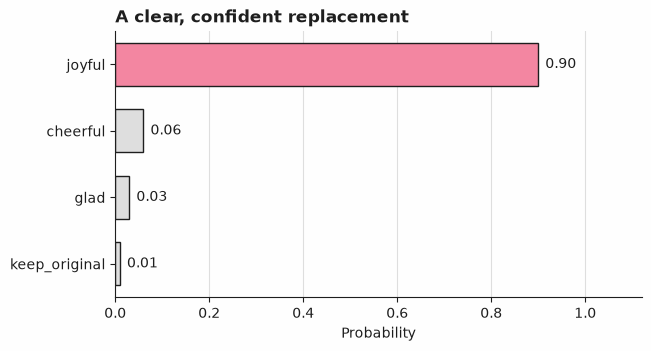

In [4]:
clear_example = demo["d01-happy-clear"]
clear_answer = decide(clear_example)
print(clear_example.fields["sentence"])
show_answer(clear_answer)
plot_answer_probabilities(clear_answer, title="A clear, confident replacement")

"She was happy and couldn't stop smiling all evening after the reunion." names a straightforward positive emotion with nothing to complicate it. The stored answer puts `joyful` on top at 0.90, so `confidence` is 0.87: `(0.90 - 0.25) / 0.75`. The other two candidates, `cheerful` and `glad`, and the fallback `keep_original`, share what is left.

It's a big ask, but I think the team can pull it off.
Choice: keep_original (confidence 0.77)
  keep_original  0.83  #################
  large          0.08  ##
  sizable        0.06  #
  massive        0.03  #
Provenance: synthetic


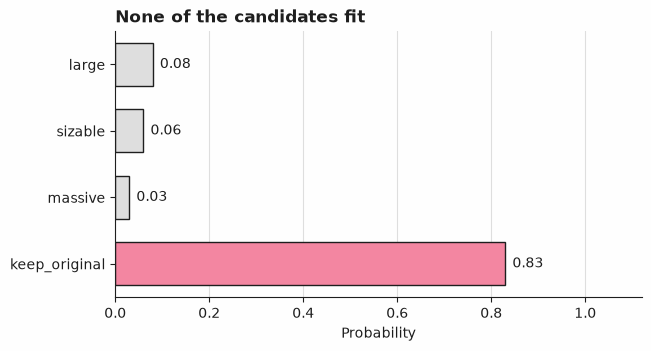

In [5]:
nomatch_example = demo["d02-big-nomatch"]
nomatch_answer = decide(nomatch_example)
print(nomatch_example.fields["sentence"])
show_answer(nomatch_answer)
plot_answer_probabilities(nomatch_answer, title="None of the candidates fit")

"It's a big ask, but I think the team can pull it off." uses `big` to mean a lot to ask for, not physically large: none of `large`, `sizable` or `massive` preserve that meaning, so the only acceptable reading is to leave the word alone. The stored answer agrees, putting `keep_original` on top at 0.83 (confidence 0.77). This is exactly the hard case the use case names, and exactly why `keep_original` is a real, final answer rather than an automatic review flag (`helpers.resolve`, below): a confident, correct `keep_original` like this one should be reported, not routed to a person for no reason.

The wind grew angry as the storm rolled in off the coast.
Choice: furious (confidence 0.73)
  furious        0.80  ################
  irritated      0.12  ##
  annoyed        0.05  #
  keep_original  0.03  #
Provenance: synthetic


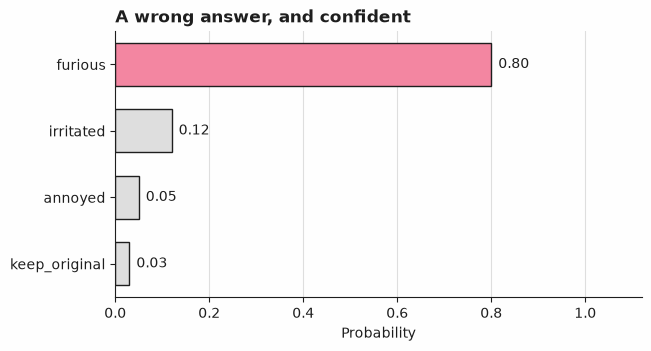

In [6]:
wrong_example = demo["d03-angry-wrong"]
wrong_answer = decide(wrong_example)
print(wrong_example.fields["sentence"])
show_answer(wrong_answer)
plot_answer_probabilities(wrong_answer, title="A wrong answer, and confident")

"The wind grew angry as the storm rolled in off the coast." personifies the wind the same way `t03-angry-nomatch` (below) personifies the sky: none of `furious`, `irritated` or `annoyed` are things wind literally feels, so the considered reading is `keep_original`. The stored answer calls it `furious` anyway, at confidence 0.73. This is a `demo` example, so nothing here is scored; it exists to show, before any aggregate number, that a wrong answer can still be a confident one -- the same shape `t05-quick-wrong` has in `test`, discussed again below once the evaluation has reported on it. Nothing here says *why* a real model would get a sentence like this wrong, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the choice; what happens with it is code. `resolve` in `helpers.py` accepts the chosen option as given only when it is one of the sentence's own candidates or `keep_original` *and* the answer's `confidence` is at or above a threshold. One thing sends it to review regardless of confidence: choosing something that was never offered -- defensive, since the criteria `build_questions` asks with never offer such an option, but the rule does not trust that silently. Unlike recipe 07's `unclear` (a Choice option that only ever means "the model could not decide", and so is sent to review whatever its confidence), `keep_original` here is a real, final answer: it is the correct, scorable outcome whenever a fixture's gold set says no candidate fits, it triggers no side effect of its own (nothing is sent, moved or changed; the sentence is simply left as written), and `resolve` holds it to exactly the same confidence gate as every other option rather than an automatic review. `tests/test_helpers.py` checks both branches for every kind of option this recipe asks about, including a confident `keep_original` reaching `accepted` rather than `review`.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose accepted subset of the 20 `validation` sentences is perfectly accurate -- "accurate" here meaning the chosen option is inside that sentence's own gold set of acceptable choices, not a single exact label, since more than one synonym can fit. `validation` has exactly one sentence, `v05-happy-wrong`, where the stored answer is wrong at a moderate confidence; excluding it from the accepted set is what the search below actually has to do, rather than landing on a threshold nothing on `validation` would have crossed anyway. Applying that frozen threshold to the three answers shown above, plus a fourth for contrast (a sentence the rule sends to review for low confidence even though it names an acceptable option), shows every outcome the rule can produce.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice in g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(
    f"answers whose choice is inside its sentence's acceptable set: {sum(val_correct)} of "
    f"{len(val_correct)}{selection}{check}"
)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

low_example = next(e for e in val_examples if e.id == "v04-happy-low")
low_answer = decide(low_example)
for shown_example, shown_answer in (
    (clear_example, clear_answer),
    (nomatch_example, nomatch_answer),
    (wrong_example, wrong_answer),
    (low_example, low_answer),
):
    candidates = shown_example.fields["candidates"]
    result = helpers.resolve(shown_example.fields["item_id"], shown_answer, candidates, threshold)
    print(
        f"{result.item_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )

answers whose choice is inside its sentence's acceptable set: 19 of 20 (a selection step, not a reported result) (a pipeline check, not a Jev result)
chosen threshold, frozen from here on: 0.7333 (a selection step, not a reported result) (a pipeline check, not a Jev result)
d01-happy-clear: joyful at confidence 0.87 -> accepted (confident)
d02-big-nomatch: keep_original at confidence 0.77 -> accepted (confident)
d03-angry-wrong: furious at confidence 0.73 -> accepted (confident)
v04-happy-low: content at confidence 0.20 -> review (confidence below the threshold)


## Evaluation

Both ingredients were chosen above: the candidates by Python, per sentence, and the confidence threshold on `validation`. This section reports what the frozen rule does: `helpers.resolve` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, this section reports the two numbers the issue asks for: the share of selections that land inside each sentence's own acceptable set -- the raw `Choice`, before the confidence gate removes anything -- and how correctly the rule uses `keep_original`: precision and recall of that one option against the sentences whose gold set says it is the only acceptable answer. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, gold, threshold):
    """Apply resolve to every answer and tally what it actually did."""
    results = [
        helpers.resolve(e.fields["item_id"], a, e.fields["candidates"], threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    in_set = [a.choice in g for a, g in zip(decided, gold, strict=True)]
    accepted = [
        (a, g)
        for r, a, g in zip(results, decided, gold, strict=True)
        if r.outcome == helpers.ACCEPTED
    ]
    right = sum(a.choice in g for a, g in accepted)
    reasons = {}
    for r in results:
        if r.outcome == helpers.REVIEW:
            reasons[r.reason] = reasons.get(r.reason, 0) + 1
    return results, in_set, len(accepted), right, reasons


val_results, val_in_set, n_accepted, n_right, val_reasons = report(
    val_examples, val_answers, val_gold, threshold
)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(
    f"selections inside the acceptable set: {sum(val_in_set)} of {len(val_in_set)} "
    f"({sum(val_in_set) / len(val_in_set):.4f}){selection}{check}"
)
print(
    f"accepted by the rule at this threshold: {n_accepted} of {len(val_examples)}{selection}{check}"
)
print(f"right among those accepted: {n_right} of {n_accepted}{selection}{check}")

validation, 20 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
selections inside the acceptable set: 19 of 20 (0.9500) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accepted by the rule at this threshold: 15 of 20 (a selection step, not a reported result) (a pipeline check, not a Jev result)
right among those accepted: 15 of 15 (a selection step, not a reported result) (a pipeline check, not a Jev result)


In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, test_in_set, n_accepted_t, n_right_t, test_reasons = report(
    test_examples, test_answers, test_gold, threshold
)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(
    f"selections inside the acceptable set: {sum(test_in_set)} of {len(test_in_set)} "
    f"({sum(test_in_set) / len(test_in_set):.4f}){check}"
)
print(f"accepted by the rule: {n_accepted_t} of {len(test_examples)}{check}")
print(f"right among those accepted: {n_right_t} of {n_accepted_t}{check}")
print(f"sent to review: {sum(test_reasons.values())} of {len(test_examples)}{check}")
for reason, count in sorted(test_reasons.items()):
    print(f"  review because {reason}: {count}{check}")

test, 20 examples, threshold 0.7333 frozen (a pipeline check, not a Jev result)
selections inside the acceptable set: 18 of 20 (0.9000) (a pipeline check, not a Jev result)
accepted by the rule: 15 of 20 (a pipeline check, not a Jev result)
right among those accepted: 14 of 15 (a pipeline check, not a Jev result)
sent to review: 5 of 20 (a pipeline check, not a Jev result)
  review because confidence below the threshold: 5 (a pipeline check, not a Jev result)


The accepted/review counts above come straight from `resolve`. This recipe's rule has a review branch beyond the confidence gate (the defensive "not a supplied option" check), so its coverage, accuracy and risk are reported with `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)`, built from what `resolve` actually decided, rather than `evaluate_selective`, which only ever compares a confidence against a threshold and would disagree with `resolve` the moment that defensive branch ever fired (`docs/evaluation.md`, "Selective prediction"). `coverage` is the fraction of all twenty `test` sentences the rule answers outright; among those, `accuracy` is the fraction whose choice lands inside the sentence's own acceptable set, and `risk` is its complement, `1 - accuracy`: the fraction of answered sentences that are wrong despite having cleared the threshold.

In [10]:
test_accepted = [r.outcome == helpers.ACCEPTED for r in test_results]
outcomes = evaluate_outcomes(test_accepted, test_in_set)
print(
    f"answered: {outcomes.n_answered} of {outcomes.n_total} "
    f"(coverage {outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {outcomes.risk:.4f}{check}")

answered: 15 of 20 (coverage 0.7500) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9333 (a pipeline check, not a Jev result)
risk among those answered: 0.0667 (a pipeline check, not a Jev result)


Five of `test`'s twenty sentences go to review instead of being reported as a result, all for the same reason, confidence below the threshold: `t04-happy-low`, `t04-big-low`, `t04-quick-low` and `t04-angry-low` each name an acceptable option too unconfidently to clear 0.7333, and `t03-angry-nomatch` misses in a different way -- its raw choice, `furious`, is wrong (the sentence personifies the sky the way `d03-angry-wrong` personifies the wind above), but at confidence 0.2267, so the gate catches it anyway. Four of the five reviewed sentences would have been right had the rule reported them anyway; only `t03-angry-nomatch` was actually a mistake the gate happened to catch. The one sentence review does not catch is `t05-quick-wrong`: the stored answer names `hasty`, which is not in its gold set (`fast`, `swift`), at a confidence of 0.80 -- comfortably above the threshold frozen on `validation` -- so the rule accepts it anyway. That is why `risk` above is 0.0667 and not 0: a threshold chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any sentence this recipe has not seen. This recipe does not teach a threshold as a guarantee it is not.

The issue asks for one more number, reported separately from the rest: how correctly the rule uses `keep_original`, the no-match outcome for a sentence whose supplied candidates do not preserve the target word's meaning. Treat this as a two-class question nested inside the larger `Choice`: was `keep_original` the only acceptable answer (the sentence's gold set), and did the raw choice actually name it? `jev_cookbook.evaluation.per_class_metrics` reports precision and recall for exactly this, the same way it would for any one class of a multi-way classification: recall is the share of truly no-match sentences the raw choice actually caught, and precision is the share of sentences where the choice said `keep_original` that really were no-match. This reads the raw choice directly, before the confidence gate above removes anything, because the issue's question is about the choice itself, not about what the rule goes on to report.

In [11]:
test_gold_class = ["keep_original" if g == ["keep_original"] else "other" for g in test_gold]
test_pred_class = [
    "keep_original" if a.choice == "keep_original" else "other" for a in test_answers
]
keep_metrics = per_class_metrics(
    test_gold_class, test_pred_class, labels=["keep_original", "other"]
)
km = keep_metrics["keep_original"]
print(f"keep_original support: {km.support} of {len(test_gold_class)}{check}")
print(f"keep_original precision: {km.precision:.4f}{check}")
print(f"keep_original recall: {km.recall:.4f}{check}")
print(f"keep_original f1: {km.f1:.4f}{check}")

keep_original support: 4 of 20 (a pipeline check, not a Jev result)
keep_original precision: 1.0000 (a pipeline check, not a Jev result)
keep_original recall: 0.7500 (a pipeline check, not a Jev result)
keep_original f1: 0.8571 (a pipeline check, not a Jev result)


The raw choice says `keep_original` for three of this split's four no-match sentences (`t03-happy-nomatch`, `t03-big-nomatch`, `t03-quick-nomatch`), giving recall 0.75, and it never says `keep_original` when a candidate actually fits, giving precision 1.0; support is 4, the number of sentences whose gold set is exactly `["keep_original"]`. The miss is `t03-angry-nomatch`: the sentence personifies the sky, and the stored answer names the literal `furious` instead. This figure is read from the raw choice, before the confidence gate: `t03-angry-nomatch` happens to also be one of the five sentences the gate above sends to review, for its own, separate reason (low confidence), so this particular miss never reaches a reader as a reported `furious` result -- but the recall figure above describes the choice itself, and a `keep_original` miss at a higher confidence would not be caught by the gate at all, the same way `t05-quick-wrong` is not.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 40 scored sentences (plus 3 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose (including one wrong *and* confident, to show what a frozen threshold does not catch), so every number above describes this fixture set and not a model.

In [12]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard sentence to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `resolve` sends it, and whether it changes the `keep_original` precision or recall above.
- Add a fifth target word with its own candidate pool, and a few sentences for it; `candidate_options` and `build_questions` need no change, since the candidate list already travels with each sentence rather than a shared per-word table.
- Neighbouring recipes: [`11-clarification-selection`](../11-clarification-selection/) and [`13-candidate-rewrite-selection`](../13-candidate-rewrite-selection/), which build a `Choice` over a fixed option set the same way this one does.